In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
# Importing required libraries as per OEL guidelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn modules for Supervised Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Scikit-learn modules for Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Scikit-learn modules for Unsupervised Learning
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 1. Handle missing or inconsistent values
# 'TotalCharges' is recognized as an object; let's convert it to numeric and handle errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values (TotalCharges has a few empty strings)
df.dropna(inplace=True)

# Drop 'customerID' as it is irrelevant for learning patterns
df.drop('customerID', axis=1, inplace=True)

# 2. Encode categorical data
# Separate features into categorical and numerical
categorical_cols = df.select_dtypes(include=['object']).columns

# We will use Label Encoding for binary categories and One-Hot Encoding for multi-class
label_encoders = {}
for col in categorical_cols:
    if df[col].nunique() == 2:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Use pandas get_dummies for variables with > 2 categories
df = pd.get_dummies(df, drop_first=True)

# 3. Normalize/Scale features
# Identify features to scale
X = df.drop('Churn', axis=1) # Churn is our target variable for supervised learning
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Preprocessing Complete. Shape of processed data:", X_scaled_df.shape)

Preprocessing Complete. Shape of processed data: (7032, 30)


/tmp/ipykernel_2378/2683463174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


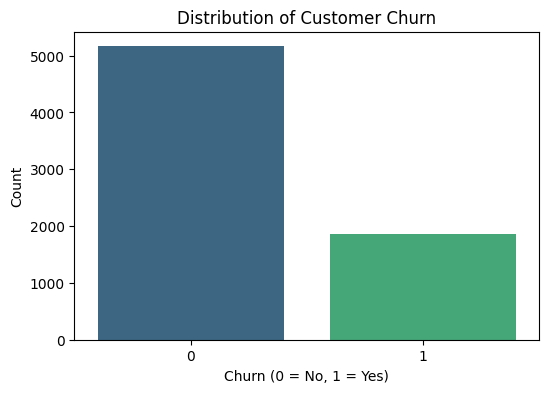

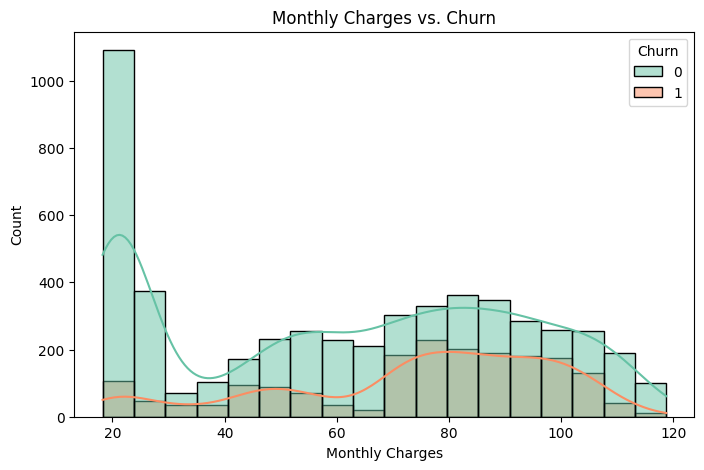

In [5]:
# Visualizing Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Visualizing continuous variables (Monthly Charges) based on Churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='Set2')
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Monthly Charges')
plt.show()

In [6]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize models requested in the rubric
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbor": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# Dictionary to store performance metrics
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[name] = [acc, prec, rec, f1, cm]

# Displaying the Results Comparison
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Confusion_Matrix'])
display(results_df.drop('Confusion_Matrix', axis=1))

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.787491,0.620579,0.516043,0.563504
Decision Tree,0.724947,0.483544,0.510695,0.496749
Random Forest,0.787491,0.638376,0.462567,0.536434
K-Nearest Neighbor,0.752665,0.536517,0.510695,0.523288
Naive Bayes,0.657427,0.428760,0.868984,0.574205


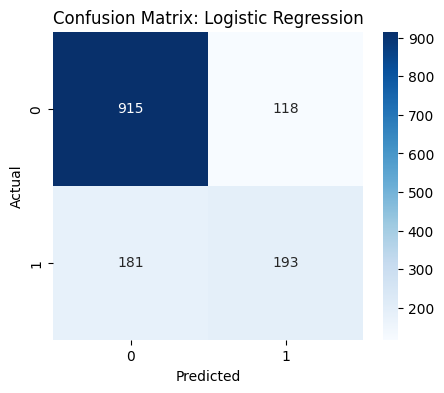

In [7]:
# Visualize the confusion matrix for the best performing model (e.g., Logistic Regression or Random Forest)
# Adjust the key below based on whichever model scores highest in your run
best_model_name = "Logistic Regression"
best_cm = results[best_model_name][4]

plt.figure(figsize=(5, 4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

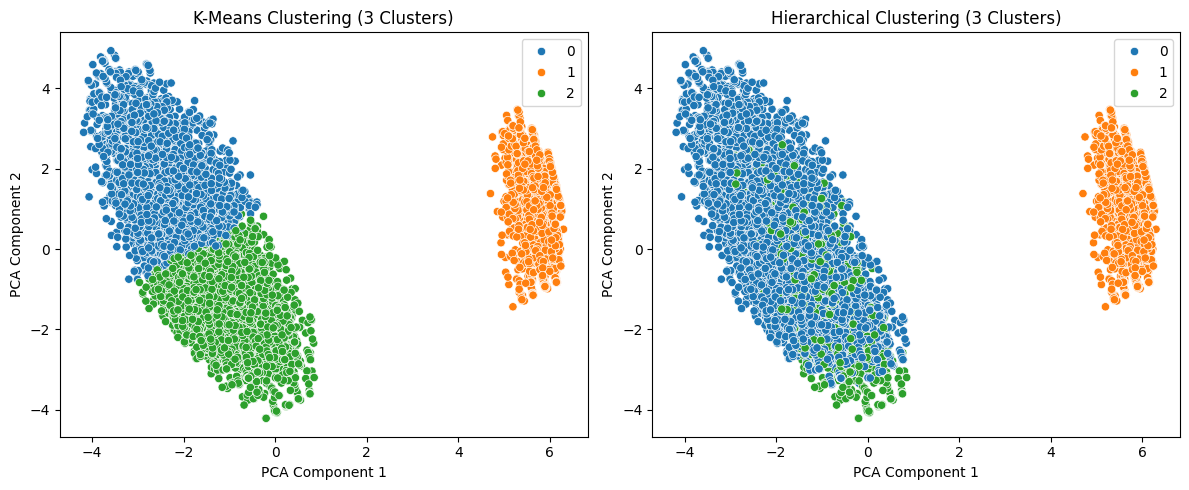

In [8]:
# For clustering, we drop the 'Churn' label completely to find natural customer groups
# To visualize clusters in 2D, we apply Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 1. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 2. Hierarchical Clustering (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Visualize K-Means Clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10')
plt.title('K-Means Clustering (3 Clusters)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Visualize Hierarchical Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hierarchical_labels, palette='tab10')
plt.title('Hierarchical Clustering (3 Clusters)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

In [10]:
import joblib

# Assuming 'Logistic Regression' was your best model from the previous steps
best_model_name = "Logistic Regression"
best_model = models[best_model_name]

# Save the trained model
joblib.dump(best_model, 'best_churn_model.pkl')

# It is also highly recommended to save your scaler for future predictions!
joblib.dump(scaler, 'standard_scaler.pkl')

print("Model and Scaler successfully saved as .pkl files!")

Model and Scaler successfully saved as .pkl files!
